# GRACE for High-Dimensional Time Series (d=30)

This notebook demonstrates GRACE (Gated Refinement After Constraint-based Estimation) on a 30-variable causal system — a regime where constraint-based methods like CDNOTS start to degrade while GRACE maintains high precision.

Benchmark results across increasing dimensionality (sparse SCP, T=1000, averaged over 10 seeds):

| d | CDNOTS F1 | GRACE F1 | GRACE Precision |
|---|-----------|----------|-----------------|
| 20 | 0.844 | 0.868 | 95.0% |
| 30 | 0.816 | 0.893 | — |
| 50 | 0.742 | 0.915 | 96.7% |
| 70 | 0.665 | 0.927 | 97.7% |
| 100 | 0.531 | 0.920 | 97.4% |

**Key insight:** At d=100, GRACE nearly doubles F1 over CDNOTS (0.92 vs 0.53) with 97.4% precision and SHD reduced by 90% (281 → 27).

In [2]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.synthetic_data.synthetic_datasets import SCPGraphGenerator
from causalts.ci_tests import PartialCorr
from causalts import run_cdnots, run_cdnots_plus
from causalts.grace import run_cdnots_gated
from causalts.utils import evaluate_graph

## 1. Generate Data

Sparse mixed linear/nonlinear SCP: d=30 variables, T=1000 time points, max_lag=5.
- `density="sparse"` — ~1.3–2.2 edges per variable
- `dependency_funcs=("lin", "lin", "nl1", "nl2")` — mixed linear/nonlinear
- `seed=0` — first of 10 seeds used in benchmarks

In [3]:
gen = SCPGraphGenerator(
    n_vars=30,
    max_lag=5,
    density="sparse",
    dependency_funcs=("lin", "lin", "nl1", "nl2"),
)
result = gen.sample(seed=0, T=1000, max_tries=500)

df = result["df"]
ground_truth = result["ground_truth"]  # shape (30, 30, 6)

n_edges = int(ground_truth.sum())
print(f"Dataset: {df.shape[0]} time points, {df.shape[1]} variables")
print(f"True causal edges: {n_edges}")

Dataset: 1000 time points, 30 variables
True causal edges: 70


## 2. CDNOTS Baseline

Constraint-based discovery with partial correlation. At d=30, conditioning sets become large relative to T=1000, causing some precision loss.

In [4]:
ci_test = PartialCorr(np.ascontiguousarray(df.values))

t0 = time.time()
_r = run_cdnots(
    df=df, indep_test=ci_test, num_lags=5,
    include_C=True, alpha=0.05,
)
graph_cdnots = _r.cg_tig
t_cdnots = time.time() - t0

graph_cdnots = graph_cdnots[:30, :30, :]
metrics_cdnots = evaluate_graph(graph_cdnots, ground_truth)

print(f"CDNOTS ({t_cdnots:.0f}s):")
print(f"  F1={metrics_cdnots['F1']:.3f}  Precision={metrics_cdnots['Precision']:.3f}"
      f"  Recall={metrics_cdnots['TPR']:.3f}  SHD={metrics_cdnots['SHD']}")
print(f"  TP={metrics_cdnots['TP']}  FP={metrics_cdnots['FP']}  FN={metrics_cdnots['FN']}")

CDNOTS (9s):
  F1=0.780  Precision=0.697  Recall=0.886  SHD=35
  TP=62  FP=27  FN=8


## 3. GRACE

GRACE uses the CDNOTS skeleton as a high-recall candidate set, then trains independent Hard Concrete gates to prune false positives.

Lambda is selected via an adaptive formula: `max(0.007 + 0.16·ρ_S, 1/d + 4/T - 0.4·ρ_S^0.8)` where ρ_S is skeleton density.

In [5]:
t0 = time.time()
_gr = run_cdnots_gated(
    df=df,
    max_lag=5,
    alpha=0.05,
    # skeleton=graph_cdnots, # we can provide the skeleton from cdnots
    gate_threshold=0.5,
    max_epochs=150,
    model_seed=42,
    verbose=True,
    ground_truth=ground_truth,
)
G_grace     = _gr.cg_tig
gate_values = _gr.gate_values
info        = {"lambda_l0": _gr.lambda_l0,
               "skeleton_density": float(_gr.skeleton.astype(bool).mean()) if _gr.skeleton is not None else None}
t_grace = time.time() - t0

metrics_grace = evaluate_graph(G_grace, ground_truth)
print(f"\nGRACE ({t_grace:.0f}s):")
print(f"  F1={metrics_grace['F1']:.3f}  Precision={metrics_grace['Precision']:.3f}"
      f"  Recall={metrics_grace['TPR']:.3f}  SHD={metrics_grace['SHD']}")
print(f"  Lambda used: {info['lambda_l0']:.4f}  Skeleton density: {info['skeleton_density']:.3f}")

ParCorrGPU requires CUDA; falling back to CPU PartialCorr


Step 1: CDNOTS skeleton discovery...


  0%|          | 0/31 [00:00<?, ?it/s]

Seed set to 42


  Skeleton: 89 edges, density=0.017 (9.8s)

Step 2: Single gated training with skeleton mask...
  lambda_L0=0.0223 (formula)
  Training done: 62 gates > 0.5 (131.9s)

Result: 62 edges at threshold=0.5 (141.6s total)
  Skeleton: 9.8s, Training: 131.9s

--- Evaluation vs Ground Truth ---
  TP=56  FP=6  FN=14  TN=5294
  TPR=0.800  FPR=0.001  Precision=0.903  F1=0.848
  SHD=20  SHD_pair=18

GRACE (142s):
  F1=0.848  Precision=0.903  Recall=0.800  SHD=20
  Lambda used: 0.0223  Skeleton density: 0.016


## 4. Gate Value Heatmap

Each gate value indicates confidence in an edge's existence. Values > 0.5 are included in the final graph.

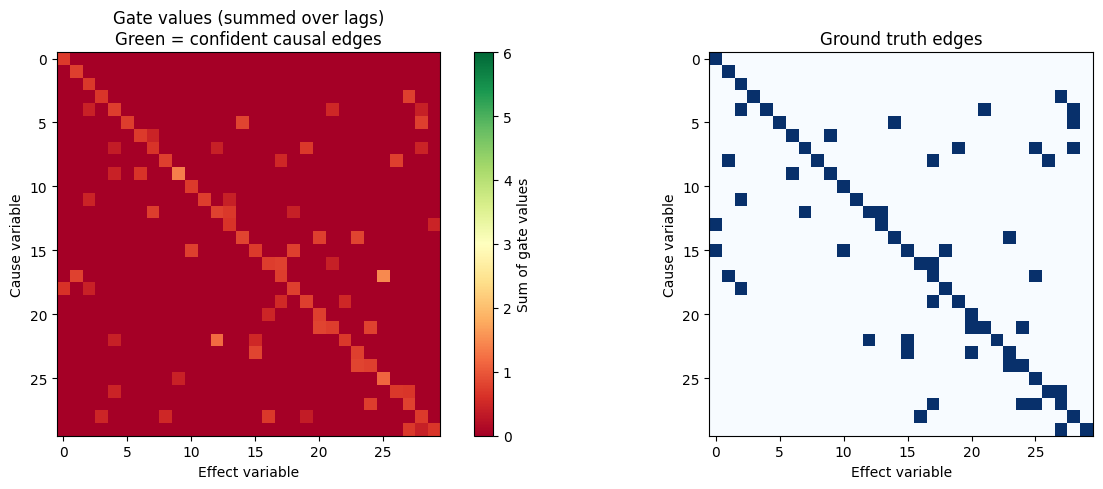

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gate_sum = gate_values.sum(axis=2)  # (d, d)
im = axes[0].imshow(gate_sum, cmap="RdYlGn", vmin=0, vmax=gate_values.shape[2])
axes[0].set_title("Gate values (summed over lags)\nGreen = confident causal edges", fontsize=12)
axes[0].set_xlabel("Effect variable")
axes[0].set_ylabel("Cause variable")
plt.colorbar(im, ax=axes[0], label="Sum of gate values")

gt_sum = ground_truth.sum(axis=2)
axes[1].imshow(gt_sum, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Ground truth edges", fontsize=12)
axes[1].set_xlabel("Effect variable")
axes[1].set_ylabel("Cause variable")

plt.tight_layout()
plt.show()

## 5. Gate Value Distribution

Hard Concrete gates produce a bimodal distribution: true causal edges concentrate near 1, false edges near 0, with almost no overlap at the 0.5 decision boundary. This makes the threshold robust without tuning.

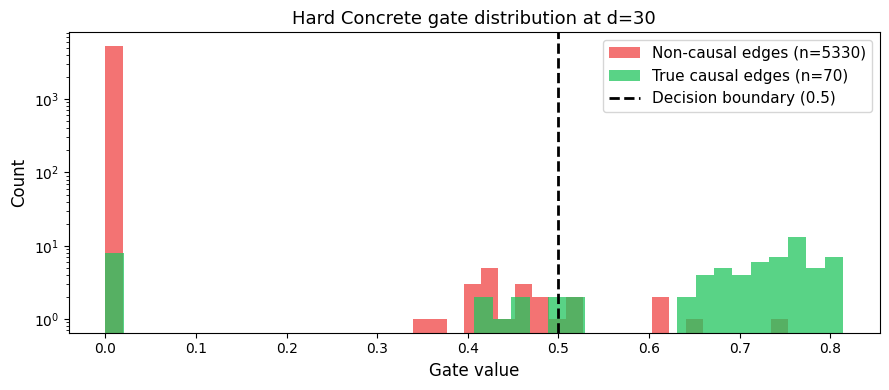

True edges with gate > 0.5: 80.0%
False edges with gate < 0.5: 99.9%


In [7]:
flat_gates = gate_values.flatten()
flat_truth = ground_truth.flatten()

true_gates  = flat_gates[flat_truth == 1]
false_gates = flat_gates[flat_truth == 0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(false_gates, bins=40, alpha=0.75, color="#ef4444",
        label=f"Non-causal edges (n={len(false_gates)})")
ax.hist(true_gates,  bins=40, alpha=0.75, color="#22c55e",
        label=f"True causal edges (n={len(true_gates)})")
ax.axvline(0.5, color="black", linestyle="--", linewidth=2, label="Decision boundary (0.5)")
ax.set_xlabel("Gate value", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_yscale("log")
ax.set_title("Hard Concrete gate distribution at d=30", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"True edges with gate > 0.5: {(true_gates > 0.5).mean()*100:.1f}%")
print(f"False edges with gate < 0.5: {(false_gates < 0.5).mean()*100:.1f}%")

## 6. Summary

In [13]:
summary = pd.DataFrame({
    "Method": ["CDNOTS", "GRACE"],
    "F1": [f"{metrics_cdnots['F1']:.3f}", f"{metrics_grace['F1']:.3f}"],
    "Precision": [f"{metrics_cdnots['Precision']:.3f}", f"{metrics_grace['Precision']:.3f}"],
    "Recall": [f"{metrics_cdnots['TPR']:.3f}", f"{metrics_grace['TPR']:.3f}"],
    "SHD": [metrics_cdnots['SHD'], metrics_grace['SHD']],
    "TP/FP/FN": [
        f"{metrics_cdnots['TP']}/{metrics_cdnots['FP']}/{metrics_cdnots['FN']}",
        f"{metrics_grace['TP']}/{metrics_grace['FP']}/{metrics_grace['FN']}",
    ],
    "Runtime (s)": [f"{t_cdnots:.0f}", f"{t_grace:.0f}"],
})
print(summary.to_string(index=False))
print(f"\nTrue edges: {n_edges}")

Method    F1 Precision Recall  SHD TP/FP/FN Runtime (s)
CDNOTS 0.780     0.697  0.886   35  62/27/8           9
 GRACE 0.848     0.903  0.800   20  56/6/14         142

True edges: 70


## Key Takeaways

- **Use GRACE when d > 20** — gating consistently improves precision with minimal recall loss
- **Lambda adapts automatically** to d, T, and skeleton density — no manual tuning
- **Gate values are interpretable**: > 0.8 = high-confidence; 0.5–0.8 = borderline; < 0.5 = pruned
- **Bimodal separation** confirms the 0.5 threshold is reliable without calibration

For d ≥ 30, run on GPU (`device='cuda'` or `device='mps'`) to reduce training time.